#  1. 인공신경망의 시작: 퍼셉트론

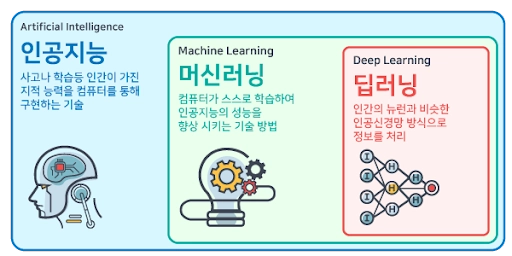

## 인공신경망
우리 뇌의 신경망을 모방한 모델
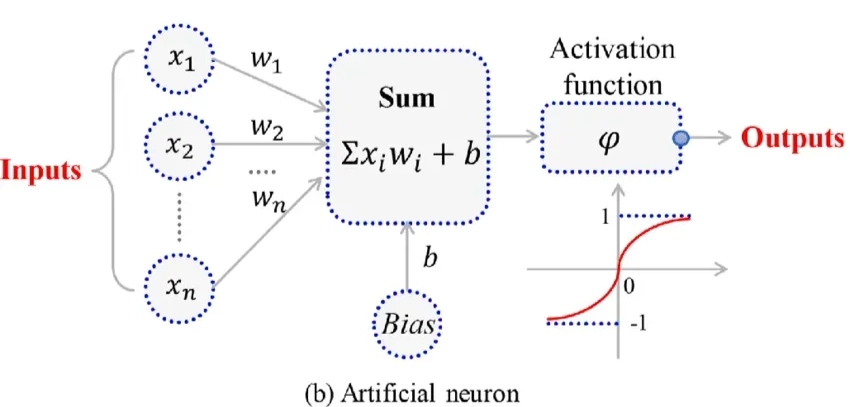

## 퍼셉트론
초기 형태의 인공신경망으로, 신경망(딥러닝)의 기원이 되는 선형 이진 분류기
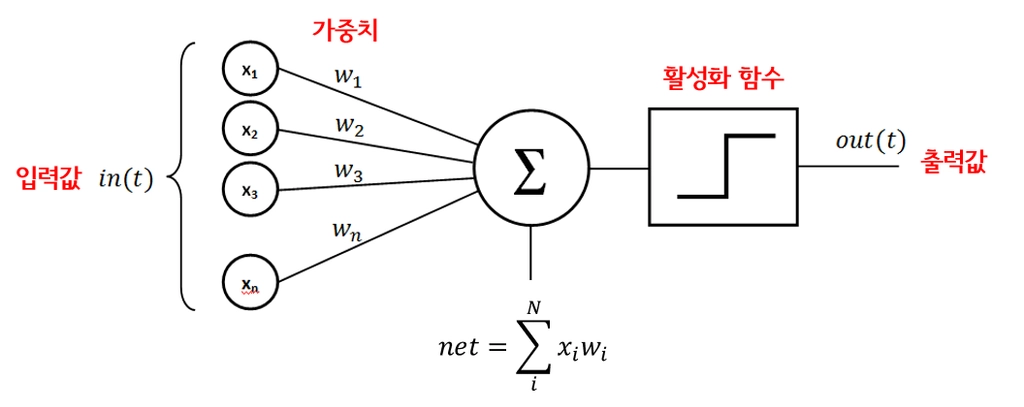
#### 활성화 함수
- 퍼셉트론 : 계단함수 사용
- 이후
    - Sigmoid (로지스틱 회귀 시간에 본 적 있었죠)
    - Tanh (-1 ~ 1의 출력을 가집니다.)
    - ReLU (음수 부분을 0으로 만들어, 양수값을 주로 다룰 때는 계산 속도상의 이점을 가지는 것이 특징입니다.)
    - leaky ReLU (ReLU에서 음수 부분에 미세한 기울기를 준 함수입니다.)

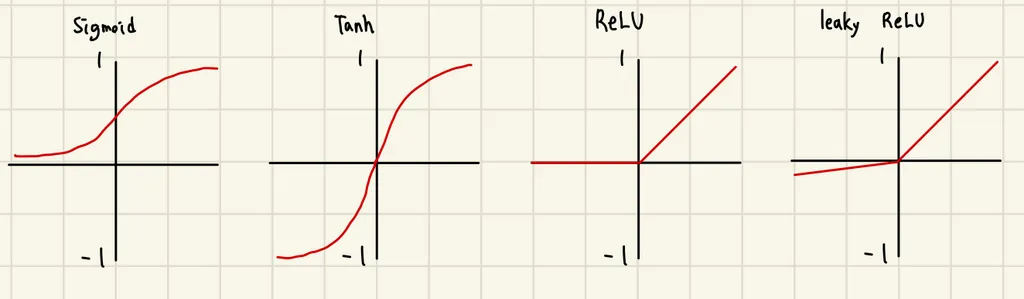
ReLU가 좋음

## 단층 퍼셉트론
단순히 입력층과 출력층으로만 이루어진 퍼셉트론  
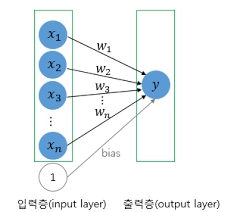

### 논리 게이트
(해당 게이트의 논리대로 결과값이 나오도록 식의 가중치와 편향을 구해서 사용한다고 생각하면 됨)
1. AND 게이트 : 입력값이 모두 1인 경우에만 출력값이 1이 나오는 구조
2. OR 게이트 : 입력값이 모두 0인 경우에 출력값이 0이고, 나머지 경우에는 모두 출력값이 1인 구조
3. NAND 게이트 : 입력값이 모두 1인 경우에만 출력값이 0, 나머지 경우에는 모두 출력값이 1인 구조
4. XOR 게이트 : 입력값 두 개가 서로 다른 값을 갖고 있을 때에만 출력값이 1인 구조

#### 단층 퍼셉트론의 한계
XOR 게이트 구현 불가 -> 다층 퍼셉트론 사용  
XOR 게이트는 직선이 아닌 곡선/비선형 영역으로 분리해야만 구현할 수 있음!
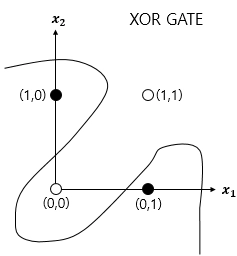


## 다층 퍼셉트론
입력층 + 하나 이상의 은닉층 + 출력층 으로 구성  
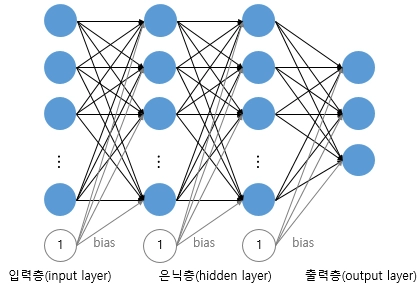  
- 두개 이상의 은닉층을 갖는 MLP가 딥러닝의 시초 모델로 발전

#  2. 딥러닝 모델은 어떻게 학습할까? 

## 학습 알고리즘 기본 구조
1. **순전파**를 통해 **입력값으로부터 예측** 수행
2. **오차(손실) 계산**을 통해 **예측 정확도** 측정
3. **역전파**를 통해 출력층에서 다시 입력층 방향으로 **오차 전달**
4. **가중치 업데이트**
5. 1~4를 반복…

## 연쇄 법칙
- 각 층이 다음 층에 미친 영향을 순서대로 곱한 값 = 입력값이 최종 출력에 영향을 미친 값 (즉, 최종 손실에 대한 원인을 단계별로 분석)
- 역전파(책임 추적하기) 과정에서 사용됨
- 손실 함수를 줄이기 위해 가중치를 어떻게 바꿀까? 를 알려주는 신호

## 기울기 소실 문제
- 은닉층이 많고, 각 단계마다 미분값이 1 미만이면, 기울기를 계속해서 곱했을 때 결국 기울기가 0에 수렴함 -> 가중치 업데이트x, 학습x

## 손실함수
실제값(정답)과 예측값(출력값)의 차이를 계산하는 데에 사용되는 함수
- **손실 함수 정리**

| **손실 함수** | **사용 상황** | **표현식** | **예시** |
| --- | --- | --- | --- |
| **MSE** | 회귀 문제 | $L = \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$ | 주택 가격 예측, 온도 예측, 주식 가격 예측 |
| **BCE** | 이진 분류 문제 | $L = -(y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}))$ | 이메일 스팸 필터링(스팸/정상), 질병 진단(양성/음성) |
| **CEE** | 다중 클래스 분류 문제 | $L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$ | 손글씨 숫자 인식(MNIST), 이미지 분류(CIFAR-10) |

## 활성화 함수
각 층의 출력값에 비선형성을 추가해서 신경망이 복잡한 패턴도 학습할 수 있게 해주는 함수

| 활성화함수 | 출력 범위 | 주요 사용처 | 장점 | 단점 |
| --- | --- | --- | --- | --- |
| 계단 함수 | 0 또는 1 | 단층 퍼셉트론 | 구조가 단순 | 미분 불가 |
| Sigmoid | 0 ~ 1 | 이진 분류 출력층 | **확률**로 해석 가능 | **기울기 소실 문제** |
| Tanh | -1 ~ 1 | 은닉층 | 출력 중심이 0으로 학습 안정적 | **기울기 소실 문제** |
| ReLU | 0 ~ ∞ | 은닉층 전반 | **계산 빠름, 기울기 소실 완화** | 음수 입력 시 출력이 항상 0 |
| Softmax | 0 ~ 1 (합=1) | 다중 분류 출력층 | 클래스별 확률 직접 출력 | 출력층 전용, 은닉층엔 부적합 |

## 경사하강법
- batch : 전체 데이터를 쪼갬 (데이터 2000개, 배치 10개 -> 배치크기 200개)
- epoch : 모든 데이터셋을 학습하는 횟수 (1회 = 전체 데이터 1번 학습)
- iteration/step : 1 epoch를 끝내기 위해 필요한 배치의 수 (1 epoch에서 다루는 데이터 수 = batch의 크기 * iteration(step))

1. 배치 경사하강법(Batch Gradient Descent) : 가장 기본, 전체 데이터를 한 묶음으로 하여 학습 및 업데이트, 메모리 부족
2. 배치 크기가 1인 확률적 경사하강법(Stochastic Gradient Descent, SGD) : 랜덤으로 선택된 하나의 데이터에 대해서만 계산, 정확도 낮음
3. 미니 배치 경사하강법(Mini-Batch Gradient Descent) : 배치 크기를 적절히 지정하여 매개 변수 값을 조정, 빠르고 안정적, 가장 많이 사용

## 옵티마이저
경사하강법을 더 효율적이고 안정적으로 수행하기 위해 필요함 (더 효과적으로 최솟값 찾기 가능)
1. 모멘텀(Momentum) : 경사하강법 + 관성
- 경사하강법에서 계산된 접선의 기울기에 바로 한 시점 전의 접선의 기울기값을 일정 비율만큼 반영
2. 알엠에스프롭(RMSProp) : 학습률 조정
- 급한 경사에서는 속도를 줄이고, 완만한 경사에서는 속도를 유지하거나 증가
3. 아담(Adam) : 위 두가지를 합친, 방향 + 스텝 사이즈(학습률)
- 각 파라미터의 1차 모멘트(기울기의 평균)을 통해 업데이트의 방향(관성)을 잡고, 2차 모멘트(기울기의 제곱 평균)를 통해 학습률을 개별적으로 조정함.

## 데이터 증감(Data Augmentation)
- 기존 데이터에서 다양한 변형을 만들어 학습 데이터를 늘리는 것
- 목적: 데이터 부족 문제 해결, 모델의 견고함(Robustness) 향상, 과적합 감소
- 적용 분야
    - 비전(이미지): 뒤집기(Flip), 회전(Rotation), 부분 자르기(Crop), 확대/축소, 밝기 조정 등
    - 자연어 처리(NLP): 동의어 대체, 랜덤 삽입/삭제, 문장 섞기, 번역 후 역번역 등
- 주의점: 변형된 데이터가 원본의 본질적인 특성을 잃지 않아야 하며, 태스크에 적절한 증강 방식을 선택해야 합니다.

- 효과
1. 모델 성능의 향상 : 모델이 일반화된 패턴을 익힘
2. 데이터 의존성 감소 : 다양한 패턴 학습
3. 과적합 완화
4. 데이터 프라이버스 보호